<a href="https://colab.research.google.com/github/nomanabdullah04/MaChineLearning/blob/MachineLearning/AlgFFdataSetFProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Resources
Here is the step-by-step implementation guide detailing every phase of the ML lifecycle.

**Phase 1: Business Understanding & Problem Framing**
Before writing code, define the business goal and translate it into a technical problem.
*   **Define success:** Set clear metrics (e.g., reduce customer churn by 5%, achieve 95% fraud detection).
*   **Identify project type:** Determine if it is a classification, regression, clustering, or generative AI problem.
*   **Assess constraints:** Check data availability, project budget, time limits, and hardware constraints.

**Phase 2: Data Collection & Ingestion**
Gather the raw data required to solve the framed problem.
*   **Identify sources:** Locate databases, APIs, CSV files, web scraping targets, or IoT sensor streams.
*   **Data storage:** Store raw data securely in a data lake (e.g., AWS S3) or a data warehouse (e.g., Snowflake).
*   **Data versioning:** Use tools like DVC (Data Version Control) to track changes in your data files over time.

**Phase 3: Data Cleaning & Preprocessing**
Prepare the raw data so that machine learning algorithms can read it without crashing.
*   **Handle missing values:** Drop columns with too many blanks, or fill them using averages (mean/median).
*   **Fix data types:** Convert text numbers to numeric types using `pd.to_numeric(..., errors='coerce')`.
*   **Remove duplicates:** Clean out redundant rows to prevent model bias.
*   **Manage outliers:** Filter out extreme, corrupted data points that could distort model training.

**Phase 4: Exploratory Data Analysis (EDA)**
Analyze the clean data visually and statistically to find patterns, anomalies, and relationships.
*   **Check distributions:** Plot histograms to see how target variables and features are spread out.
*   **Correlation analysis:** Create heatmaps to find which features correlate strongest with your target.
*   **Visualize anomalies:** Use scatter plots and box plots to spot hidden clusters or data shifts.

**Phase 5: Feature Engineering & Selection**
Transform raw variables into highly informative features that boost model performance.
*   **Encoding:** Turn categorical text (like "Red", "Blue") into numbers using One-Hot or Label Encoding.
*   **Scaling:** Normalize numerical features to a uniform scale (e.g., 0 to 1) using StandardScaler or MinMaxScaler.
*   **Feature creation:** Combine columns to make new ones (e.g., dividing Distance by Time to create a Speed feature).
*   **Feature selection:** Drop highly redundant or useless features to keep the model fast and lightweight.

**Phase 6: Model Training & Hyperparameter Tuning**
Train candidate models on your processed data to find the best-performing algorithm.
*   **Data splitting:** Divide your data into Training (70%), Validation (15%), and Testing (15%) sets.
*   **Baseline training:** Start with simple algorithms (e.g., Linear Regression, Decision Trees) to set a benchmark.
*   **Hyperparameter tuning:** Use LassoCV, GridSearchCV, or RandomizedSearchCV to fine-tune model settings and find optimal regularization strengths (alpha_).
*   **Cross-Validation:** Use K-Fold cross-validation to ensure model performance is stable across different data splits.

**Phase 7: Model Evaluation & Validation**
Test the finalized model on unseen data to ensure it generalizes well to the real world.
*   **Classification metrics:** Check Accuracy, Precision, Recall, F1-Score, and the ROC-AUC score.
*   **Regression metrics:** Evaluate Mean Absolute Error (MAE), Mean Squared Error (MSE), and \(R^{2}\) Score.
*   **Overfitting check:** Compare training performance against testing performance to ensure the model didn't just memorize the training data.

**Phase 8: Model Deployment**
Move the trained model out of your notebook and into a production environment where users can access it.
*   **Model serialization:** Save the trained model object as a file using pickle or joblib.
*   **API creation:** Wrap the model file in a web framework like FastAPI or Flask to accept data requests.
*   **Containerization:** Pack the API, model, and code dependencies into a Docker container for consistent deployment.
*   **Cloud hosting:** Deploy the container to a cloud platform (AWS, Google Cloud, Azure) or an ML platform (Hugging Face, SageMaker).

**Phase 9: Monitoring & Maintenance**
Track the model's health in production and update it when real-world conditions change.
*   **Monitor performance:** Track latency (speed), system errors, and prediction distributions.
*   **Detect Data Drift:** Watch for shifts in incoming real-world data compared to the historical training data.
*   **CI/CD retraining pipelines:** Set up automated scripts to retrain and redeploy the model periodically with fresh data.

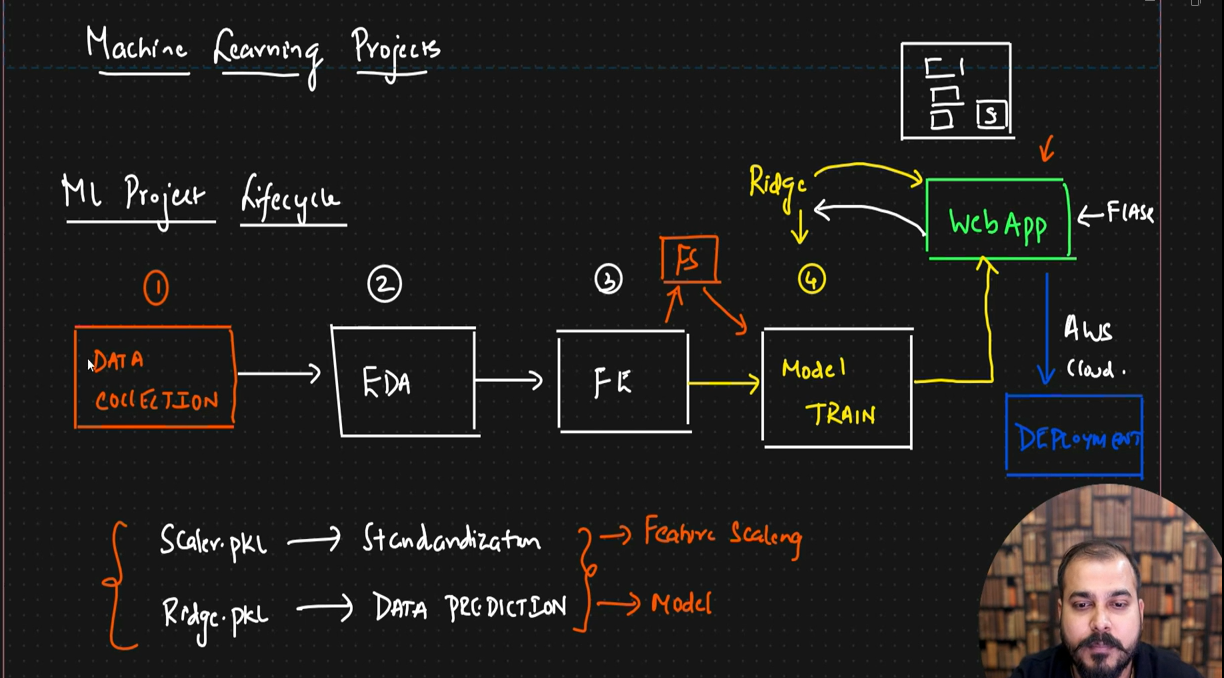

# In this step we will import basic liberis

In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [108]:
dataset=pd.read_csv("/content/Algerian_forest_fires_dataset.csv")

In [109]:
dataset.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


# **Data Cleaning Process**

In [110]:
dataset.isnull().sum()

,0
day,1
month,2
year,2
Temperature,2
RH,2
Ws,2
Rain,2
FFMC,2
DMC,2
DC,2


In [111]:
dataset[dataset.isnull().any(axis=1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
122,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
123,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
168,14,7,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN


In [112]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247 entries, 0 to 246
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          246 non-null    object
 1   month        245 non-null    object
 2   year         245 non-null    object
 3   Temperature  245 non-null    object
 4    RH          245 non-null    object
 5    Ws          245 non-null    object
 6   Rain         245 non-null    object
 7   FFMC         245 non-null    object
 8   DMC          245 non-null    object
 9   DC           245 non-null    object
 10  ISI          245 non-null    object
 11  BUI          245 non-null    object
 12  FWI          245 non-null    object
 13  Classes      244 non-null    object
dtypes: object(14)
memory usage: 27.1+ KB


In [113]:
dataset.loc[[122,123]]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
122,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
123,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [114]:
dataset = dataset.drop([122,123]).reset_index(drop=True)

In [115]:
dataset[dataset.isnull().any(axis=1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
166,14,7,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN


This file includes 244 instances that regroup a data of two regions of Algeria, namely the Bejaia region located in the northeast of Algeria and the Sidi Bel-abbes region located in the northwest of Algeria.

In [116]:
dataset.loc[:122,'Region']=0
dataset.loc[122:,'Region']=1
df=dataset

In [117]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0.0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0.0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0.0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0.0
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0.0


In [118]:
df.tail()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
240,26,9,2012,30,65,14,0,85.4,16,44.5,4.5,16.9,6.5,fire,1.0
241,27,9,2012,28,87,15,4.4,41.1,6.5,8,0.1,6.2,0,not fire,1.0
242,28,9,2012,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,not fire,1.0
243,29,9,2012,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,not fire,1.0
244,30,9,2012,24,64,15,0.2,67.3,3.8,16.5,1.2,4.8,0.5,not fire,1.0


In [119]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 245 entries, 0 to 244
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          245 non-null    object 
 1   month        245 non-null    object 
 2   year         245 non-null    object 
 3   Temperature  245 non-null    object 
 4    RH          245 non-null    object 
 5    Ws          245 non-null    object 
 6   Rain         245 non-null    object 
 7   FFMC         245 non-null    object 
 8   DMC          245 non-null    object 
 9   DC           245 non-null    object 
 10  ISI          245 non-null    object 
 11  BUI          245 non-null    object 
 12  FWI          245 non-null    object 
 13  Classes      244 non-null    object 
 14  Region       245 non-null    float64
dtypes: float64(1), object(14)
memory usage: 28.8+ KB


In [120]:
df['Region']=df['Region'].astype(int)

In [121]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 245 entries, 0 to 244
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          245 non-null    object
 1   month        245 non-null    object
 2   year         245 non-null    object
 3   Temperature  245 non-null    object
 4    RH          245 non-null    object
 5    Ws          245 non-null    object
 6   Rain         245 non-null    object
 7   FFMC         245 non-null    object
 8   DMC          245 non-null    object
 9   DC           245 non-null    object
 10  ISI          245 non-null    object
 11  BUI          245 non-null    object
 12  FWI          245 non-null    object
 13  Classes      244 non-null    object
 14  Region       245 non-null    int64 
dtypes: int64(1), object(14)
memory usage: 28.8+ KB


In [122]:
df.dropna().reset_index(drop=True)

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,26,9,2012,30,65,14,0,85.4,16,44.5,4.5,16.9,6.5,fire,1
240,27,9,2012,28,87,15,4.4,41.1,6.5,8,0.1,6.2,0,not fire,1
241,28,9,2012,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,not fire,1
242,29,9,2012,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,not fire,1


In [123]:
df.isnull().sum()

,0
day,0
month,0
year,0
Temperature,0
RH,0
Ws,0
Rain,0
FFMC,0
DMC,0
DC,0


In [124]:
df.columns=df.columns.str.strip()
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

Change the required Column, those are integrer as int type and float are float type

In [125]:
int_cols = ['day','month','year','Temperature','RH','Ws']
float_cols = ['Rain','FFMC','DMC','DC','ISI','BUI','FWI']

# Apply to_numeric with errors='coerce' to all these columns to handle non-numeric entries
for col in int_cols + float_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows where any of these critical numeric columns resulted in NaN (e.g., duplicated header rows)
df.dropna(subset=int_cols + float_cols, inplace=True)

# Now, after handling non-numeric entries, convert to desired types
df[int_cols] = df[int_cols].astype(int)
df[float_cols] = df[float_cols].astype(float)

In [126]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 243 entries, 0 to 244
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    int64  
 1   month        243 non-null    int64  
 2   year         243 non-null    int64  
 3   Temperature  243 non-null    int64  
 4   RH           243 non-null    int64  
 5   Ws           243 non-null    int64  
 6   Rain         243 non-null    float64
 7   FFMC         243 non-null    float64
 8   DMC          243 non-null    float64
 9   DC           243 non-null    float64
 10  ISI          243 non-null    float64
 11  BUI          243 non-null    float64
 12  FWI          243 non-null    float64
 13  Classes      243 non-null    object 
 14  Region       243 non-null    int64  
dtypes: float64(7), int64(7), object(1)
memory usage: 30.4+ KB


In [127]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [128]:
df.to_csv('Algerian_forest_fires_cleaned.csv', index=False)

In [129]:
from google.colab import files
files.download('Algerian_forest_fires_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Exploratory Data Analysis**

In [130]:
#Drop day ,month and years
df=df.drop(['day','month','year'],axis=1)

In [131]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


**Categorical Data convert into biary form 0 ,1**

In [132]:
df['Classes'].value_counts()

,count
Classes,
fire,131
not fire,101
fire,4
fire,2
not fire,2
not fire,1
not fire,1
not fire,1


In [133]:
# Explicitly convert the 'Classes' column to string type to handle any non-string entries
df['Classes'] = df['Classes'].astype(str)

# Strip any leading/trailing whitespace from the 'Classes' values
df['Classes'] = df['Classes'].str.strip()

# Convert 'Classes' to 0 for 'not fire' and 1 for 'fire'
df['Classes'] = np.where(df['Classes'].str.contains('not fire'), 0, 1)

# Ensure the column is of integer type
df['Classes'] = df['Classes'].astype(int)

In [134]:
df['Classes'].value_counts()

,count
Classes,
1,137
0,106


It appears the `df` DataFrame was inadvertently filtered earlier, resulting in only 6 rows. To get the correct counts for 'Classes', we need to re-create `df` from the `dataset` variable (which contains the 243 rows after initial cleaning) and re-apply the data preparation steps.

In [135]:
# Re-assign df from dataset to restore the full DataFrame
df = dataset.copy()

# Ensure 'Region' column is correctly set and typed (as per previous steps)
df.loc[:122,'Region']=0
df.loc[122:,'Region']=1
df['Region'] = df['Region'].astype(int)

# Strip column names again, just in case
df.columns=df.columns.str.strip()

# Re-apply numeric conversions and drop rows with NaNs in critical columns (from cell oYdNiPYRTQ96)
int_cols = ['day','month','year','Temperature','RH','Ws']
float_cols = ['Rain','FFMC','DMC','DC','ISI','BUI','FWI']

for col in int_cols + float_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.dropna(subset=int_cols + float_cols + ['Classes'], inplace=True) # Include 'Classes' in dropna subset

df[int_cols] = df[int_cols].astype(int)
df[float_cols] = df[float_cols].astype(float)

# Drop 'day', 'month', 'year' columns (from cell w7yTT0Sk8sW1)
df = df.drop(['day','month','year'],axis=1)

# Now, re-apply the 'Classes' encoding (from cell zmFojb18_N6s)
df['Classes'] = df['Classes'].astype(str)
df['Classes'] = df['Classes'].str.strip()
df['Classes'] = np.where(df['Classes'].str.contains('not fire'), 0, 1)
df['Classes'] = df['Classes'].astype(int)

df['Classes'].value_counts()

,count
Classes,
1,137
0,106


In [136]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [179]:
#I want this for my web appliction

df.to_csv('Algerian_forest_fires_cleaned.csv', index=False)

In [180]:
from google.colab import files
files.download('Algerian_forest_fires_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [137]:
df.tail()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
240,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,6.5,1,1
241,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0.0,0,1
242,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,0,1
243,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,0,1
244,24,64,15,0.2,67.3,3.8,16.5,1.2,4.8,0.5,0,1


In [138]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 243 entries, 0 to 244
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  243 non-null    int64  
 1   RH           243 non-null    int64  
 2   Ws           243 non-null    int64  
 3   Rain         243 non-null    float64
 4   FFMC         243 non-null    float64
 5   DMC          243 non-null    float64
 6   DC           243 non-null    float64
 7   ISI          243 non-null    float64
 8   BUI          243 non-null    float64
 9   FWI          243 non-null    float64
 10  Classes      243 non-null    int64  
 11  Region       243 non-null    int64  
dtypes: float64(7), int64(5)
memory usage: 32.8 KB


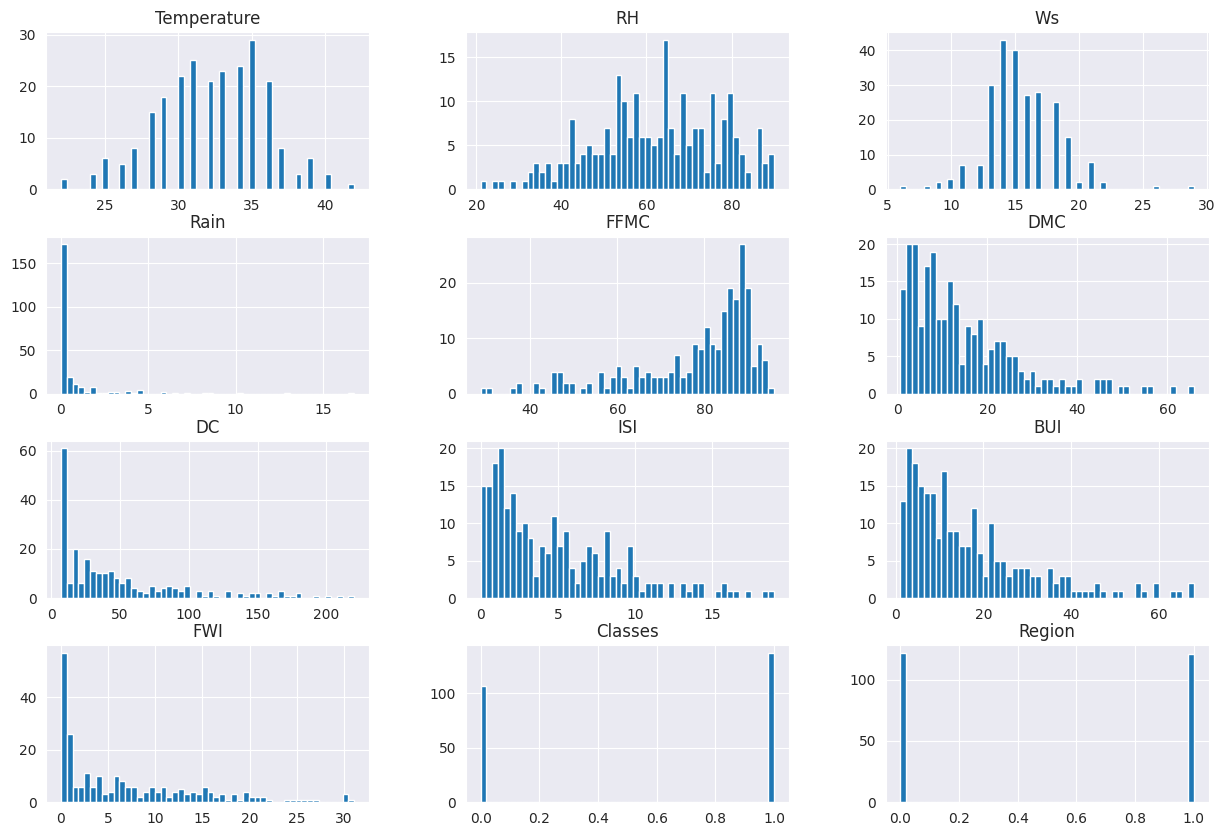

In [139]:
#Plot density plot for all feature
sns.set_style('darkgrid')
df.hist(bins=50,figsize=(15,10))
plt.show()

In [140]:
#Percentage for pie chart
precentage=df['Classes'].value_counts(normalize=True)*100
print(precentage)

Classes
1    56.378601
0    43.621399
Name: proportion, dtype: float64


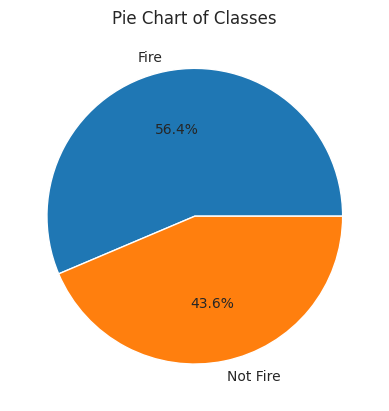

In [141]:
#Plotting piec Chart
classlabels=['Fire','Not Fire']
plt.pie(precentage,labels=classlabels,autopct='%1.1f%%')
plt.title('Pie Chart of Classes')
plt.show()

In [142]:
#Define the correlation
df.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
Temperature,1.000000,-0.651400,-0.284510,-0.326492,0.676568,0.485687,0.376284,0.603871,0.459789,0.566670,0.516015,0.269555
RH,-0.651400,1.000000,0.244048,0.222356,-0.644873,-0.408519,-0.226941,-0.686667,-0.353841,-0.580957,-0.432161,-0.402682
Ws,-0.284510,0.244048,1.000000,0.171506,-0.166548,-0.000721,0.079135,0.008532,0.031438,0.032368,-0.069964,-0.181160
Rain,-0.326492,0.222356,0.171506,1.000000,-0.543906,-0.288773,-0.298023,-0.347484,-0.299852,-0.324422,-0.379097,-0.040013
FFMC,0.676568,-0.644873,-0.166548,-0.543906,1.000000,0.603608,0.507397,0.740007,0.592011,0.691132,0.769492,0.222241
DMC,0.485687,-0.408519,-0.000721,-0.288773,0.603608,1.000000,0.875925,0.680454,0.982248,0.875864,0.585658,0.192089
DC,0.376284,-0.226941,0.079135,-0.298023,0.507397,0.875925,1.000000,0.508643,0.941988,0.739521,0.511123,-0.078734
ISI,0.603871,-0.686667,0.008532,-0.347484,0.740007,0.680454,0.508643,1.000000,0.644093,0.922895,0.735197,0.263197
BUI,0.459789,-0.353841,0.031438,-0.299852,0.592011,0.982248,0.941988,0.644093,1.000000,0.857973,0.586639,0.089408
FWI,0.566670,-0.580957,0.032368,-0.324422,0.691132,0.875864,0.739521,0.922895,0.857973,1.000000,0.719216,0.197102


<Axes: >

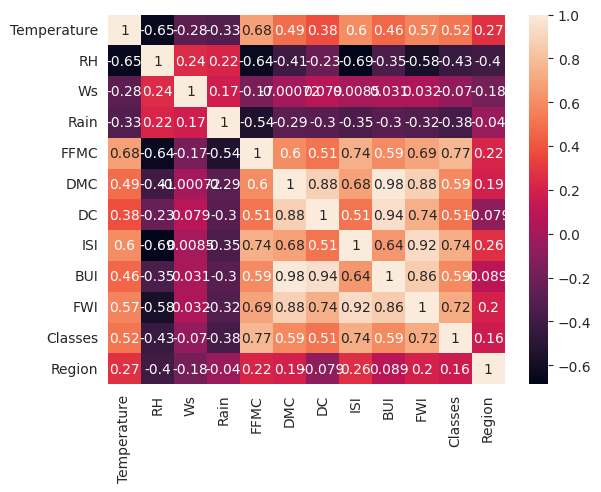

In [143]:
sns.heatmap(df.corr(),annot=True)

# Check Outlier By using Box Plots

<Axes: ylabel='FWI'>

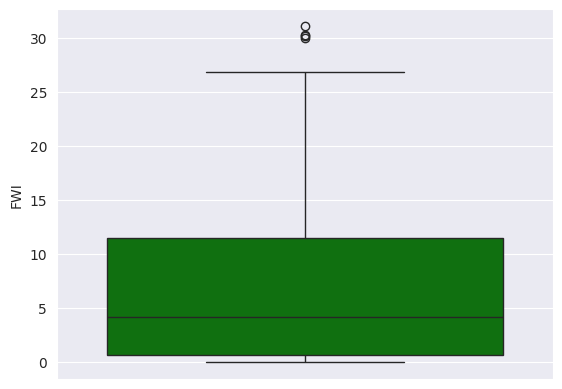

In [144]:
sns.boxplot(df['FWI'],color='g')

In [145]:
df['Classes'] = df['Classes'].map({0: 'not fire', 1: 'fire'})

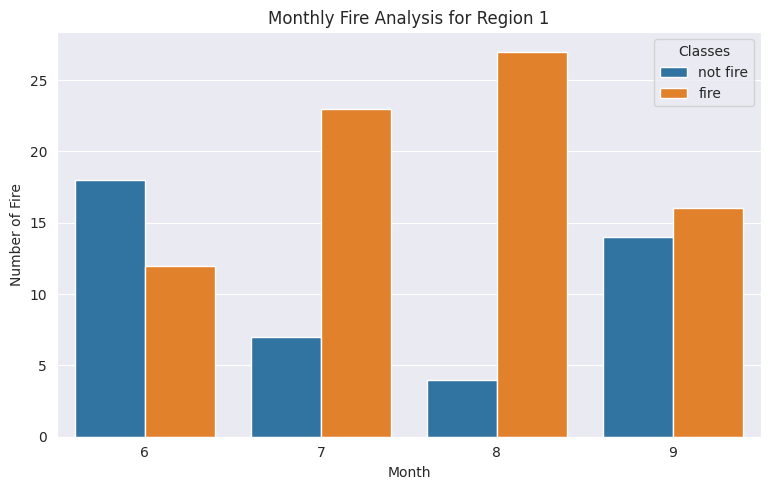

In [146]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

#Monthly Fire Analysis
# Corrected: Create a figure with the desired figsize
plt.figure(figsize=(15,5))

# Create a temporary DataFrame for this plot that retains the 'month' column
# and has 'Classes' and 'Region' in the correct format for analysis.
# We'll use a copy of the 'dataset' which contains the 'month' column before it was dropped from 'df'.
df_monthly_analysis = dataset.copy()

# Ensure 'Region' is an integer type (consistent with earlier cleaning of the main 'df')
df_monthly_analysis['Region'] = df_monthly_analysis['Region'].astype(int)

# Strip any leading/trailing whitespace from 'Classes' values for consistency in plotting
df_monthly_analysis['Classes'] = df_monthly_analysis['Classes'].astype(str).str.strip()

# Apply the region filter, consistent with the original `dftem` creation
df_monthly_analysis_region1 = df_monthly_analysis.loc[df_monthly_analysis['Region']==1]

# Create the first subplot in a 1x2 grid at position 1
plt.subplot(1,2,1)
sns.set_style('darkgrid')

# Use the temporary filtered DataFrame for the countplot, which now has the 'month' column.
sns.countplot(x='month', hue='Classes', data=df_monthly_analysis_region1)
plt.ylabel('Number of Fire') # Corrected typo 'Nuber' to 'Number'
plt.xlabel('Month')
plt.title('Monthly Fire Analysis for Region 1')

# Add plt.tight_layout() to prevent labels from overlapping and plt.show() to display the plot
plt.tight_layout()
plt.show()

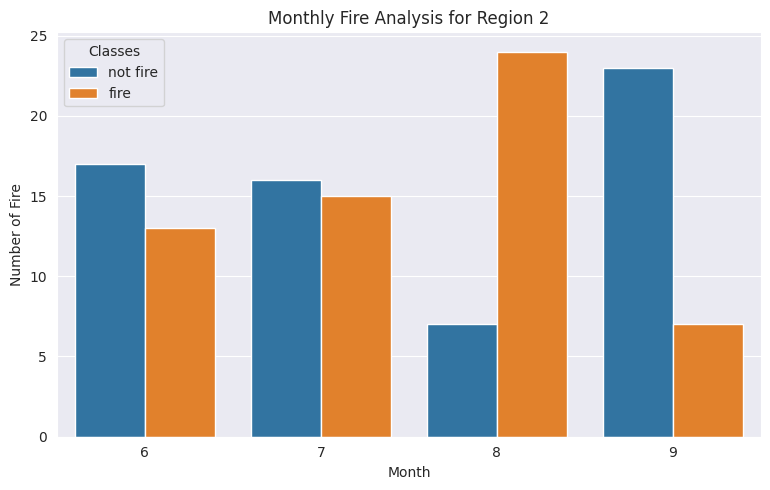

In [147]:
#Monthly Fire Analysis for the Region 2
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Corrected: Create a figure with the desired figsize
plt.figure(figsize=(15,5))
df_monthly_analysis = dataset.copy()
df_monthly_analysis['Region'] = df_monthly_analysis['Region'].astype(int)
df_monthly_analysis['Classes'] = df_monthly_analysis['Classes'].astype(str).str.strip()
df_monthly_analysis_region2 = df_monthly_analysis.loc[df_monthly_analysis['Region']==0]

# Create the second subplot in the same grid at position 2
plt.subplot(1,2,2)
sns.set_style('darkgrid')
sns.countplot(x='month', hue='Classes', data=df_monthly_analysis_region2)
plt.ylabel('Number of Fire')
plt.xlabel('Month')
plt.title('Monthly Fire Analysis for Region 2')

# Add plt.tight_layout() to prevent labels from overlapping and plt.show() to display the plot
plt.tight_layout()
plt.show()

# **Model Traning**

In [148]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [149]:
df['Classes']=np.where(df['Classes']=="not fire",0,1)

In [150]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [151]:
df.tail()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
240,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,6.5,1,1
241,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0.0,0,1
242,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,0,1
243,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,0,1
244,24,64,15,0.2,67.3,3.8,16.5,1.2,4.8,0.5,0,1


In [152]:
df['Classes'].value_counts()

,count
Classes,
1,137
0,106


In [153]:
#Define the independet and Dependent Variable
x=df.drop('FWI',axis=1)
y=df['FWI']

In [154]:
x

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,0
...,...,...,...,...,...,...,...,...,...,...,...
240,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,1,1
241,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0,1
242,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0,1
243,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0,1


In [155]:
y

,FWI
0,0.5
1,0.4
2,0.1
3,0.0
4,0.5
...,...
240,6.5
241,0.0
242,0.2
243,0.7


In [156]:
# Re-assign df from dataset to restore the full DataFrame with all preprocessing
df = dataset.copy()

# Ensure 'Region' column is correctly set and typed (as per previous steps)
df.loc[:122,'Region']=0
df.loc[122:,'Region']=1
df['Region'] = df['Region'].astype(int)

# Strip column names again, just in case
df.columns=df.columns.str.strip()

# Re-apply numeric conversions and drop rows with NaNs in critical columns
int_cols = ['day','month','year','Temperature','RH','Ws']
float_cols = ['Rain','FFMC','DMC','DC','ISI','BUI','FWI']

for col in int_cols + float_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.dropna(subset=int_cols + float_cols + ['Classes'], inplace=True)

df[int_cols] = df[int_cols].astype(int)
df[float_cols] = df[float_cols].astype(float)

# Drop 'day', 'month', 'year' columns
df = df.drop(['day','month','year'],axis=1)

# Now, re-apply the 'Classes' encoding
df['Classes'] = df['Classes'].astype(str)
df['Classes'] = df['Classes'].str.strip()
df['Classes'] = np.where(df['Classes'].str.contains('not fire'), 0, 1)
df['Classes'] = df['Classes'].astype(int)

# Save the processed DataFrame to CSV
df.to_csv('Algerian_forest_fires_cleaned.csv', index=False)

# Download the file
from google.colab import files
files.download('Algerian_forest_fires_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Train split the Data

In [157]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [158]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((182, 11), (61, 11), (182,), (61,))

In [159]:
x_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.656095,-0.305977,-0.317512,0.694768,0.498173,0.390684,0.629848,0.473609,0.542141,0.254549
RH,-0.656095,1.000000,0.225736,0.241656,-0.653023,-0.414601,-0.236078,-0.717804,-0.362317,-0.456876,-0.394665
Ws,-0.305977,0.225736,1.000000,0.251932,-0.190076,0.000379,0.096576,-0.023558,0.035633,-0.082570,-0.199969
Rain,-0.317512,0.241656,0.251932,1.000000,-0.545491,-0.289754,-0.302341,-0.345707,-0.300964,-0.369357,-0.059022
FFMC,0.694768,-0.653023,-0.190076,-0.545491,1.000000,0.620807,0.524101,0.750799,0.607210,0.781259,0.249514
DMC,0.498173,-0.414601,0.000379,-0.289754,0.620807,1.000000,0.868647,0.685656,0.983175,0.617273,0.212582
DC,0.390684,-0.236078,0.096576,-0.302341,0.524101,0.868647,1.000000,0.513701,0.942414,0.543581,-0.060838
ISI,0.629848,-0.717804,-0.023558,-0.345707,0.750799,0.685656,0.513701,1.000000,0.643818,0.742977,0.296441
BUI,0.473609,-0.362317,0.035633,-0.300964,0.607210,0.983175,0.942414,0.643818,1.000000,0.612239,0.114897
Classes,0.542141,-0.456876,-0.082570,-0.369357,0.781259,0.617273,0.543581,0.742977,0.612239,1.000000,0.188837


<Axes: >

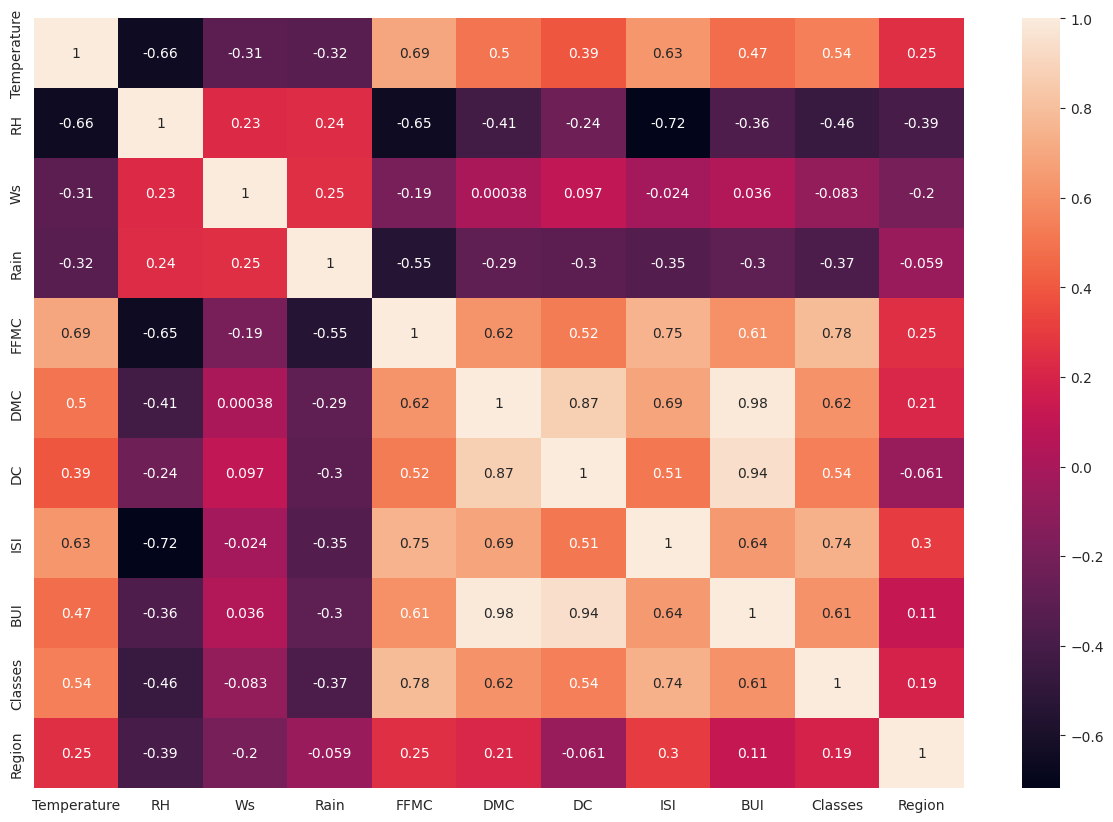

In [160]:
#Check the multicollinearity
plt.figure(figsize=(15,10))
sns.heatmap(x_train.corr(),annot=True)

In [161]:
def correlation(dataset, threshold):
    col_corr = set()  # Set of all the names of correlated columns
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
          if abs(corr_matrix.iloc[i, j]) > threshold: # we are interested in absolute coeff value
            colname = corr_matrix.columns[i]  # getting the name of column
            col_corr.add(colname)
    return col_corr

In [162]:
#Threshould-Dolain experties
corr_features = correlation(x_train, 0.85)
print(corr_features)

{'BUI', 'DC'}


In [163]:
#Drope features when correlation in more then 0.85
x_train.drop(corr_features,axis=1,inplace=True)
x_test.drop(corr_features,axis=1,inplace=True)

In [164]:
x_train.shape,x_test.shape

((182, 9), (61, 9))

# Feature Scaling or Standradization

In [165]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train_scaled=sc.fit_transform(x_train)
x_test_scaled=sc.transform(x_test)

In [166]:
x_train_scaled

array([[-0.84284248,  0.78307967,  1.29972026, ..., -0.62963326,
        -1.10431526, -0.98907071],
       [-0.30175842,  0.64950844, -0.59874754, ..., -0.93058524,
        -1.10431526,  1.01105006],
       [ 2.13311985, -2.08870172, -0.21905398, ...,  2.7271388 ,
         0.90553851,  1.01105006],
       ...,
       [-1.9250106 ,  0.9166509 ,  0.54033314, ..., -1.06948615,
        -1.10431526, -0.98907071],
       [ 0.50986767, -0.21870454,  0.16063958, ...,  0.5973248 ,
         0.90553851,  1.01105006],
       [-0.57230045,  0.98343651,  2.05910739, ..., -0.86113478,
        -1.10431526, -0.98907071]])

# Box plot to understand the effect of Standard Scaler

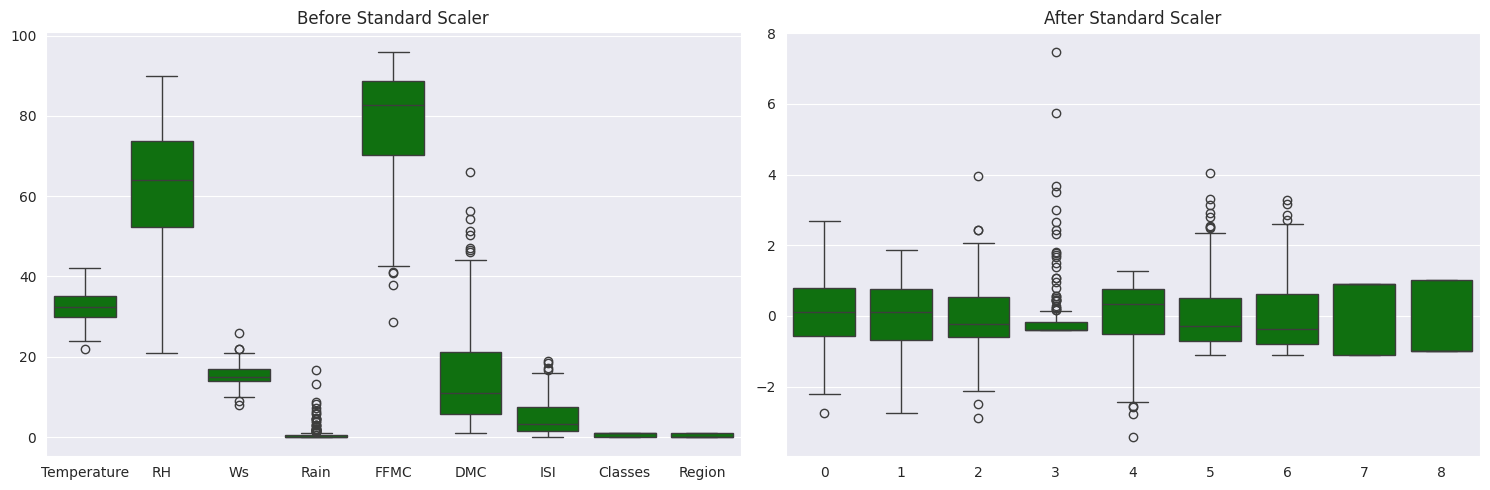

In [167]:
plt.figure(figsize=(15,5)) # Define the overall figure size here

plt.subplot(1,2,1)
sns.boxplot(x_train,color='g')
plt.title('Before Standard Scaler')

plt.subplot(1,2,2)
sns.boxplot(x_train_scaled,color='g')
plt.title('After Standard Scaler')

plt.tight_layout() # Adjust layout to prevent overlapping
plt.show()

# **Apply the linera Regression Models**

MSE: 0.6742766873791607
MAE: 0.5468236465249986
R2: 0.9847657384266951


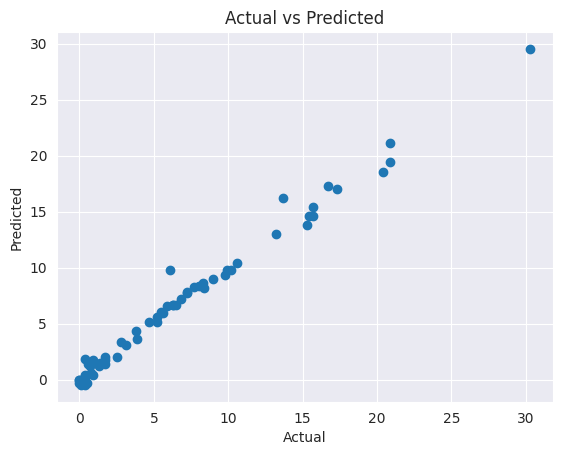

In [168]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
Lireg=LinearRegression()
Lireg.fit(x_train_scaled,y_train)
y_pred=Lireg.predict(x_test_scaled)
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print("MSE:",mse)
print("MAE:",mae)
print("R2:",r2)
#Apply Scatter Plt
plt.scatter(y_test,y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.show()

# **Apply the Lesso Regression**

In [169]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
lasso=Lasso()
lasso.fit(x_train_scaled,y_train)
y_pred=lasso.predict(x_test_scaled)
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print("MSE:",mse)
print("MAE:",mae)
print("R2:",r2)

MSE: 2.2483458918974772
MAE: 1.133175994914409
R2: 0.9492020263112388


# Apply Lesso CV regression

In [170]:
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
lasso=LassoCV(cv=5)
lasso.fit(x_train_scaled,y_train)
y_pred=lasso.predict(x_test_scaled)
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print("MSE:",mse)
print("MAE:",mae)
print("R2:",r2)

MSE: 0.792499555474362
MAE: 0.619970115826343
R2: 0.9820946715928275


# **Apply the Ridge Rigression**

MSE: 0.6949198918152074
MAE: 0.5642305340105692
R2: 0.9842993364555513


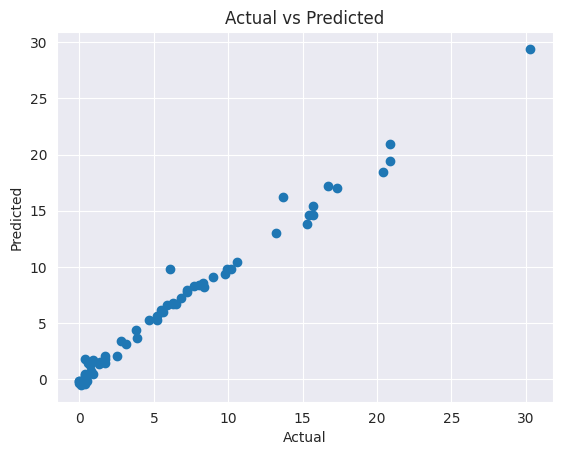

In [171]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
ridge=Ridge()
ridge.fit(x_train_scaled,y_train)
y_pred=ridge.predict(x_test_scaled)
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print("MSE:",mse)
print("MAE:",mae)
print("R2:",r2)
plt.scatter(y_test,y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.show()

# Apply the Ridge CV

MSE: 0.6949198918152074
MAE: 0.5642305340105692
R2: 0.9842993364555513


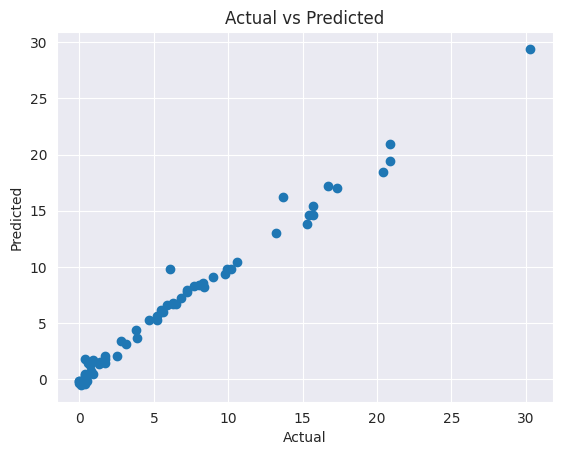

In [172]:
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
ridge=RidgeCV(cv=5)
ridge.fit(x_train_scaled,y_train)
y_pred=ridge.predict(x_test_scaled)
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print("MSE:",mse)
print("MAE:",mae)
print("R2:",r2)
plt.scatter(y_test,y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.show()

# **Apply the ElasicNet Regression**

MSE: 5.5172511010252245
MAE: 1.8822353634896005
R2: 0.8753460589519703


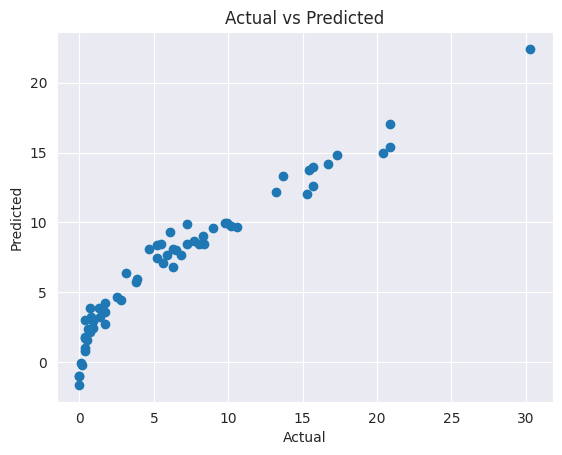

In [173]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
elastic=ElasticNet()
elastic.fit(x_train_scaled,y_train)
y_pred=elastic.predict(x_test_scaled)
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print("MSE:",mse)
print("MAE:",mae)
print("R2:",r2)
plt.scatter(y_test,y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.show()

# Apply the ElasticNet CV

MSE: 0.8222830416276258
MAE: 0.6575946731430898
R2: 0.9814217587854941


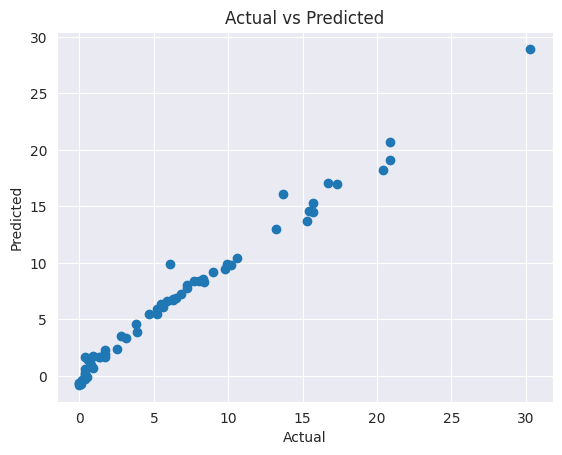

In [174]:
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
elastic=ElasticNetCV(cv=5)
elastic.fit(x_train_scaled,y_train)
y_pred=elastic.predict(x_test_scaled)
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print("MSE:",mse)
print("MAE:",mae)
print("R2:",r2)
plt.scatter(y_test,y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.show()

# **Pickle the machine learning models,Preprocessing models Standard Scaler**

In [175]:
sc

StandardScaler()

In [176]:
ridge

RidgeCV(cv=5)

In [177]:
import pickle
pickle.dump(sc,open('StandardScaler.pkl','wb'))
pickle.dump(ridge,open('ridge.pkl','wb'))

In [178]:
from google.colab import files
files.download('StandardScaler.pkl')
files.download('ridge.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>